In [21]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from tqdm import tqdm
from scipy.cluster.hierarchy import  linkage,dendrogram
from sklearn.model_selection import train_test_split
from sklearn.cluster import  KMeans
import matplotlib.pyplot as plt

In [22]:
df=pd.read_csv("../Datasets/milk.csv",index_col=0)

In [23]:
scaler=StandardScaler().set_output(transform="pandas")
df_scale=scaler.fit_transform(df)

In [24]:
k_means=KMeans(random_state=25,n_clusters=3,n_init=10)
k_means.fit(df_scale)
print(k_means.labels_)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 2 2]


In [25]:
wss=[]
for i in range(2,11):
    cluster=KMeans(random_state=25,n_clusters=i,n_init=10)
    cluster.fit(df_scale)
    wss.append([i,cluster.inertia_])
wss_df=pd.DataFrame(wss,columns=["cluster","inertia"]).sort_values(by="inertia",ascending=False)
print(wss_df)



   cluster    inertia
0        2  49.854660
1        3  30.822631
2        4  18.390116
3        5  13.355156
4        6  10.586920
5        7   7.851896
6        8   6.075610
7        9   4.883256
8       10   3.693505


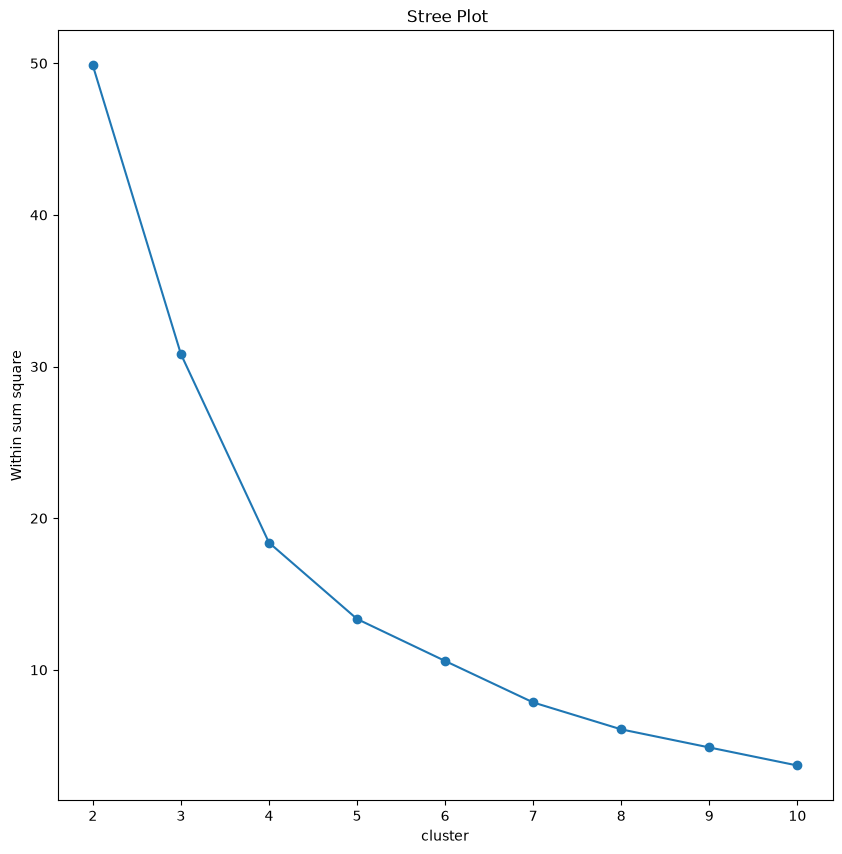

In [26]:
plt.figure(figsize=(10,10))
plt.scatter(wss_df["cluster"],wss_df["inertia"])
plt.plot(wss_df["cluster"],wss_df["inertia"])
plt.title(" Stree Plot")
plt.xlabel("cluster")
plt.ylabel("Within sum square")
plt.show()

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

scores = []

for i in range(2, 11):
    cluster = KMeans(
        random_state=25,
        n_clusters=i,
        n_init=10
    )
    cluster.fit(df_scale)
    wss = cluster.inertia_
    sil_score = silhouette_score(
        df_scale,
        cluster.labels_
    )

    scores.append([i, wss, sil_score])


score_df = pd.DataFrame(
    scores,
    columns=["cluster", "inertia", "silhouette_score"]
)

print(score_df)


   cluster    inertia  silhouette_score
0        2  49.854660          0.525851
1        3  30.822631          0.539160
2        4  18.390116          0.437608
3        5  13.355156          0.409260
4        6  10.586920          0.386462
5        7   7.851896          0.398780
6        8   6.075610          0.397209
7        9   4.883256          0.406707
8       10   3.693505          0.407573


In [35]:
df_copy=df.copy()

In [36]:
print(df_copy.nunique())

water      23
protein    25
fat        25
lactose    22
ash        22
dtype: int64


In [37]:
milk_scale=scaler.fit_transform(df_copy)

In [38]:
clusters=KMeans(random_state=25,n_clusters=2)
clusters.fit(df_copy)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",25
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 5)","[

In [43]:
df_copy["cluster"]=clusters.labels_
print(df_copy.groupby("cluster").mean())
print(df_copy["cluster"])


             water   protein        fat   lactose       ash
cluster                                                    
0        62.662500  9.700000  22.675000  2.300000  1.276250
1        85.488235  4.570588   4.488235  4.994118  0.668824
Animal
HORSE         1
ORANGUTAN     1
MONKEY        1
DONKEY        1
HIPPO         1
CAMEL         1
BISON         1
BUFFALO       1
GUINEA PIG    1
CAT           1
FOX           1
LLAMA         1
MULE          1
PIG           1
ZEBRA         1
SHEEP         1
DOG           1
ELEPHANT      0
RABBIT        0
RAT           0
DEER          0
REINDEER      0
WHALE         0
SEAL          0
DOLPHIN       0
Name: cluster, dtype: int32


In [50]:
print(df_copy[df_copy["cluster"]==0])

          water  protein   fat  lactose   ash  cluster
Animal                                                
ELEPHANT   70.7      3.6  17.6      5.6  0.63        0
RABBIT     71.3     12.3  13.1      1.9  2.30        0
RAT        72.5      9.2  12.6      3.3  1.40        0
DEER       65.9     10.4  19.7      2.6  1.40        0
REINDEER   64.8     10.7  20.3      2.5  1.40        0
WHALE      64.8     11.1  21.2      1.6  1.70        0
SEAL       46.4      9.7  42.0      0.0  0.85        0
DOLPHIN    44.9     10.6  34.9      0.9  0.53        0


In [51]:
print(df_copy[df_copy["cluster"]==1])

            water  protein  fat  lactose   ash  cluster
Animal                                                 
HORSE        90.1      2.6  1.0      6.9  0.35        1
ORANGUTAN    88.5      1.4  3.5      6.0  0.24        1
MONKEY       88.4      2.2  2.7      6.4  0.18        1
DONKEY       90.3      1.7  1.4      6.2  0.40        1
HIPPO        90.4      0.6  4.5      4.4  0.10        1
CAMEL        87.7      3.5  3.4      4.8  0.71        1
BISON        86.9      4.8  1.7      5.7  0.90        1
BUFFALO      82.1      5.9  7.9      4.7  0.78        1
GUINEA PIG   81.9      7.4  7.2      2.7  0.85        1
CAT          81.6     10.1  6.3      4.4  0.75        1
FOX          81.6      6.6  5.9      4.9  0.93        1
LLAMA        86.5      3.9  3.2      5.6  0.80        1
MULE         90.0      2.0  1.8      5.5  0.47        1
PIG          82.8      7.1  5.1      3.7  1.10        1
ZEBRA        86.2      3.0  4.8      5.3  0.70        1
SHEEP        82.0      5.6  6.4      4.7  0.91  

In [28]:
df_nut=pd.read_csv("../Datasets/nutrient.csv",index_col=0)

In [29]:
scaler=StandardScaler().set_output(transform="pandas")
df_scale_nut=scaler.fit_transform(df_nut)

In [30]:
k_means=KMeans(random_state=25,n_clusters=3,n_init=10)
k_means.fit(df_scale_nut)
print(k_means.labels_)

[0 0 0 0 1 1 1 1 0 0 0 0 0 1 1 1 2 2 1 1 1 1 1 1 1 1 1]


In [31]:
wss=[]
for i in range(2,11):
    cluster=KMeans(random_state=25,n_clusters=i,n_init=10)
    cluster.fit(df_scale_nut)
    wss.append([i,cluster.inertia_])
wss_df=pd.DataFrame(wss,columns=["cluster","inertia"]).sort_values(by="inertia",ascending=False)
print(wss_df)

   cluster    inertia
0        2  89.244368
1        3  61.538713
2        4  42.400373
3        5  29.255895
4        6  23.138882
5        7  17.945842
6        8  12.906119
7        9  10.867702
8       10   9.093318


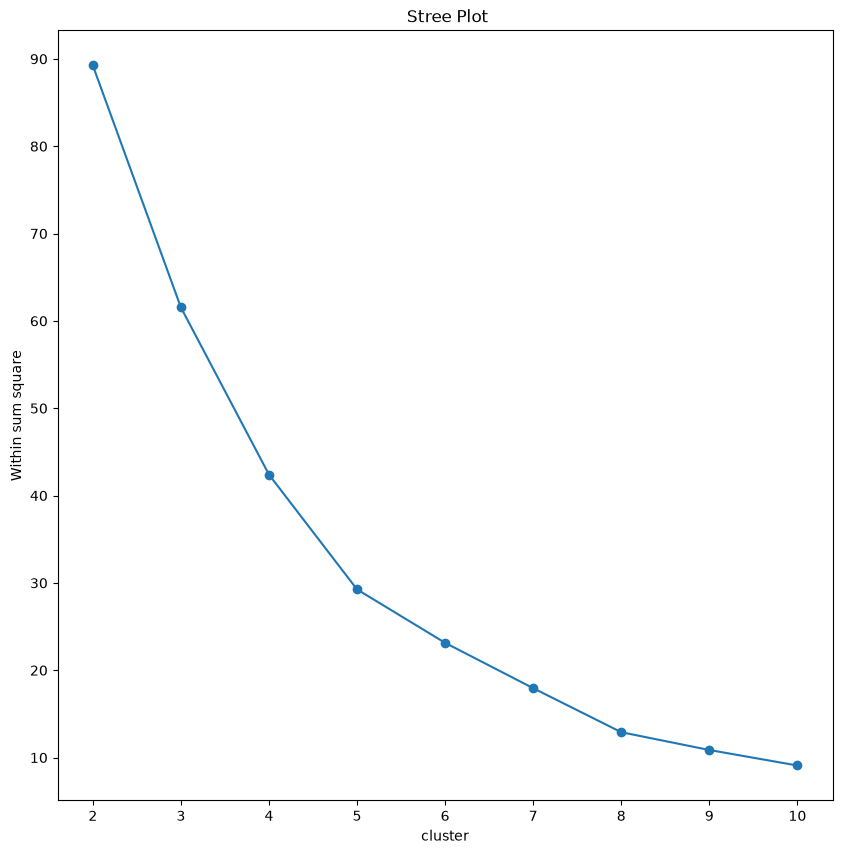

In [32]:
plt.figure(figsize=(10,10))
plt.scatter(wss_df["cluster"],wss_df["inertia"])
plt.plot(wss_df["cluster"],wss_df["inertia"])
plt.title(" Stree Plot")
plt.xlabel("cluster")
plt.ylabel("Within sum square")
plt.show()

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

scores = []

for i in range(2, 11):
    cluster = KMeans(
        random_state=25,
        n_clusters=i,
        n_init=10
    )
    cluster.fit(df_scale_nut)
    wss = cluster.inertia_
    sil_score = silhouette_score(
        df_scale_nut,
        cluster.labels_
    )

    scores.append([i, wss, sil_score])


score_df = pd.DataFrame(
    scores,
    columns=["cluster", "inertia", "silhouette_score"]
).sort_values("silhouette_score",ascending=False)

In [34]:
print(score_df)

   cluster    inertia  silhouette_score
2        4  42.400373          0.419974
1        3  61.538713          0.403772
7        9  10.867702          0.403653
3        5  29.255895          0.401050
6        8  12.906119          0.395725
5        7  17.945842          0.384535
8       10   9.093318          0.374734
4        6  23.138882          0.369750
0        2  89.244368          0.325778


In [52]:
df_copy=df_nut.copy()

In [55]:
clusters=KMeans(random_state=25,n_clusters=4)
clusters.fit(df_scale_nut)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",25
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 5)","[

In [56]:
df_copy["cluster"]=clusters.labels_
print(df_copy.groupby("cluster").mean())
print(df_copy["cluster"])

             energy    protein        fat     calcium      iron
cluster                                                        
0        151.666667  18.333333   7.666667  227.666667  1.666667
1        341.875000  18.750000  28.875000    8.750000  2.437500
2        163.928571  20.714286   7.714286   19.857143  2.028571
3         57.500000   9.000000   1.000000   78.000000  5.700000
Food_Item
BEEF BRAISED           1
HAMBURGER              2
BEEF ROAST             1
BEEF STEAK             1
BEEF CANNED            2
CHICKEN BROILED        2
CHICKEN CANNED         2
BEEF HEART             2
LAMB LEG ROAST         1
LAMB SHOULDER ROAST    1
SMOKED HAM             1
PORK ROAST             1
PORK SIMMERED          1
BEEF TONGUE            2
VEAL CUTLET            2
BLUEFISH BAKED         2
CLAMS RAW              3
CLAMS CANNED           3
CRABMEAT CANNED        2
HADDOCK FRIED          2
MACKEREL BROILED       2
MACKEREL CANNED        0
PERCH FRIED            2
SALMON CANNED          0
SARDIN

In [61]:
print(df_copy[df_copy["cluster"]==0])

                 energy  protein  fat  calcium  iron  cluster
Food_Item                                                    
MACKEREL CANNED     155       16    9      157   1.8        0
SALMON CANNED       120       17    5      159   0.7        0
SARDINES CANNED     180       22    9      367   2.5        0


In [62]:
print(df_copy[df_copy["cluster"]==1])

                     energy  protein  fat  calcium  iron  cluster
Food_Item                                                        
BEEF BRAISED            340       20   28        9   2.6        1
BEEF ROAST              420       15   39        7   2.0        1
BEEF STEAK              375       19   32        9   2.6        1
LAMB LEG ROAST          265       20   20        9   2.6        1
LAMB SHOULDER ROAST     300       18   25        9   2.3        1
SMOKED HAM              340       20   28        9   2.5        1
PORK ROAST              340       19   29        9   2.5        1
PORK SIMMERED           355       19   30        9   2.4        1


In [59]:
print(df_copy[df_copy["cluster"]==2])

energy     14
protein    14
fat        14
calcium    14
iron       14
cluster    14
dtype: int64


In [60]:
print(df_copy[df_copy["cluster"]==3].count())

energy     2
protein    2
fat        2
calcium    2
iron       2
cluster    2
dtype: int64
